In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import cifar10

train, test= cifar10.load_data()

In [3]:
X_train, y_train = train[0][:40000], train[1][:40000]
X_valid, y_valid = train[0][40000:], train[1][40000:]
X_test, y_test= test[0], test[1]

In [4]:
#Scaling the 0-255 values down to 0-1
X_train, X_valid, X_test= X_train/255, X_valid/255, X_test/255

In [5]:
labels = np.array([
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
])

In [6]:
y_train, y_valid, y_test = (y_train == 3), (y_valid == 3), (y_test == 3) #cat  vs non cat

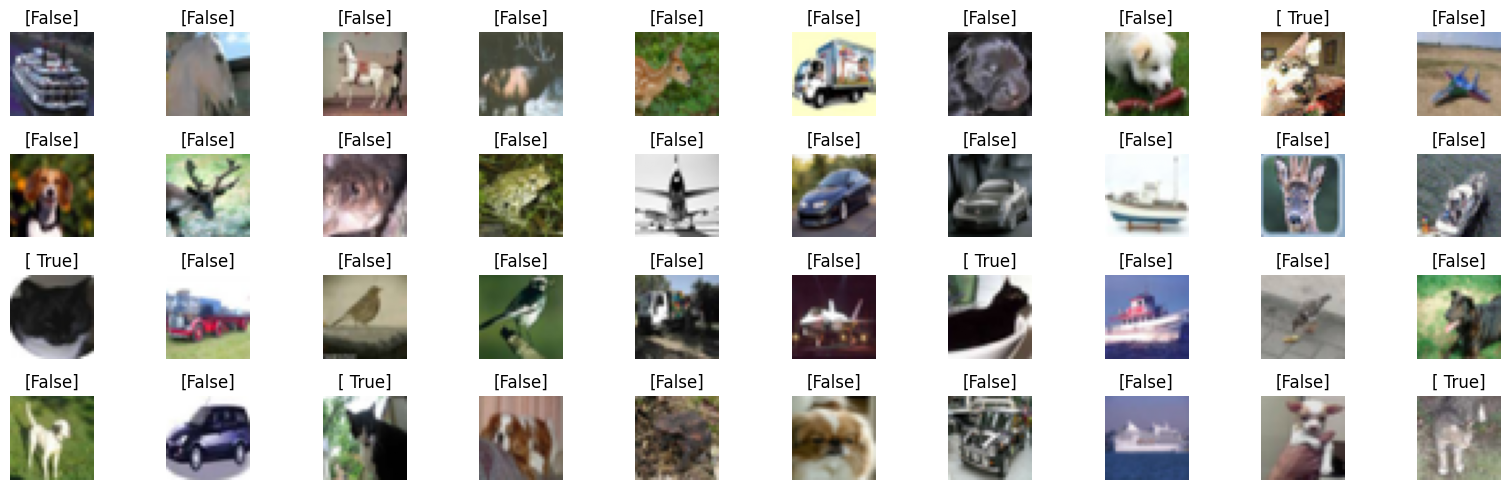

In [7]:
fig, axes= plt.subplots(4,10, figsize= (16,5))

indices= np.random.choice(40000, 40, replace= False)

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(y_train[i])
    ax.axis("off")

plt.tight_layout()

We can see clearly some of the cats are impossible to identify.. case in point

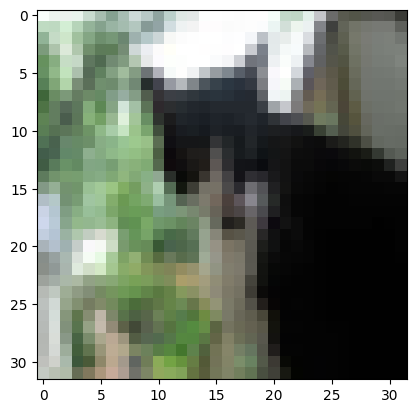

In [8]:
plt.imshow(X_train[indices[-8]])

Now how is this a cat

In [9]:
np.unique(y_train, return_counts=True)

(array([False,  True]), array([36016,  3984], dtype=int64))

In [10]:
from tensorflow.keras.models import load_model

#Let's see what the base model was doing
model = load_model("cifar_dafault_model.keras")

In [11]:
y_valid_pred= model.predict(X_valid)
y_valid_pred = np.argmax(y_valid_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
y_valid_pred= (y_valid_pred == 3)

In [13]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_valid, y_valid_pred)

array([[8091,  893],
       [ 599,  417]], dtype=int64)

So in our validation set.. 
1) We have 893 Non Cats being Predicted as Cats
2) We have 599 Cats not being classified properly  


Let's improve on this then

We don't need to use dropout here, because we want the model to specialize and specifically improve on cats.. focus is not on generalization

Most of the stuff we tried so far kind off failed.. We need to get a 50/50 split in both our trainign and validation set and ultimatey, we gotta modify them

In [14]:
# cat_classifier = tf.keras.Sequential([ 
#     tf.keras.layers.Flatten(input_shape= [32,32, 3]),
#     tf.keras.layers.Dense(300, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dropout(rate = 0.03),
#     tf.keras.layers.Dense(150, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dropout(rate = 0.02),
#     tf.keras.layers.Dense(150, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dense(80, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dense(40, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dense(20, activation= "tanh", kernel_initializer="GlorotNormal"), 
#     tf.keras.layers.Dense(10, activation= "tanh", kernel_initializer="GlorotNormal"),
#     tf.keras.layers.Dense(1, activation= "sigmoid"), 
# ])

In [15]:
# cat_classifier.compile(
#     loss= ["binary_crossentropy"], 
#     optimizer= "adam", 
#     metrics= ["accuracy"])

In [16]:
# history = cat_classifier.fit(X_train, y_train, epochs= 20, 
#                              validation_data=  (X_valid, y_valid), class_weight= {0:1, 1:9})

In [17]:
# y_pred= cat_classifier.predict(X_valid)

In [18]:
# print("min:", y_pred.min())
# print("max:", y_pred.max())
# print("mean:", y_pred.mean())
# print("std:", y_pred.std())

In [19]:
# print(y_pred[:20].reshape(-1))

In [20]:
# print(np.percentile(y_pred, [0, 1, 5, 25, 50, 75, 95, 99, 100]))

So everything's a non cat.. lol.. It's just going from 0.1 to 0.48 to minimize loss.. but it still believes the best way is to call everything a non cat

In [21]:
# y_valid_pred = (y_pred>=0.5).astype(int)
# confusion_matrix(y_valid, y_valid_pred)

In [22]:
X_train.shape

(40000, 32, 32, 3)

In [23]:
y_train[:, 0]

array([False, False, False, ..., False, False, False])

In [24]:
(y_train[:, 0] == True).sum()

3984

In [25]:
np.where(y_train[:, 0] == True)[0]


array([    9,    17,    21, ..., 39979, 39980, 39989], dtype=int64)

In [26]:
cat_idx = np.where(y_train[:, 0] == True)[0]
noncat_idx = np.where(y_train[:, 0] == False)[0]

# Randomly select 4,000 non-cat images
np.random.seed(42) 
noncat_idx_subset = np.random.choice(noncat_idx, size=3984, replace=False)
subset_idx = np.concatenate([cat_idx, noncat_idx_subset])

np.random.shuffle(subset_idx)

X_train_b = X_train[subset_idx] 
y_train_b = y_train[subset_idx]


In [27]:
X_train_b.shape

(7968, 32, 32, 3)

In [28]:
y_train_b.shape

(7968, 1)

We have to extract some data from X_valid

In [29]:
(y_valid == True).sum()

1016

I say take 500 cat images more for training.. X_valid will be shortened to only 1000 images.. (500 cats and 500 non cats)

In [30]:
cat_vidx = np.where(y_valid[:, 0] == True)[0]
noncat_vidx = np.where(y_valid[:, 0] == False)[0]

np.random.seed(42) 
cat_idx_vsub = np.random.choice(cat_vidx, size = 500, replace = False)
noncat_idx_vsub = np.random.choice(noncat_vidx, size=500, replace=False)

subset_vidx = np.concatenate([cat_idx_vsub, noncat_idx_vsub])
np.random.shuffle(subset_vidx)

X_valid_sub = X_valid[subset_vidx]
y_valid_sub = y_valid[subset_vidx]

X_train_b = np.concatenate([X_train_b, X_valid_sub])
y_train_b = np.concatenate([y_train_b, y_valid_sub])


In [31]:
X_train_b.shape

(8968, 32, 32, 3)

In [32]:
valid_mask = np.ones(len(X_valid), dtype=bool)
valid_mask[subset_vidx] = False

X_valid = X_valid[valid_mask]
y_valid = y_valid[valid_mask]

In [33]:
(y_valid == True).sum()

516

In [34]:
cat_vdx = np.where(y_valid[:, 0] == True)[0]
noncat_vdx = np.where(y_valid[:, 0] == False)[0]

np.random.seed(42) 
noncat_vdx_vsub = np.random.choice(noncat_vdx, size=516, replace=False)

subset_vdx = np.concatenate([cat_vdx, noncat_vdx_vsub])
np.random.shuffle(subset_vdx)

X_valid = X_valid[subset_vdx]
y_valid = y_valid[subset_vdx]


In [35]:
X_valid.shape

(1032, 32, 32, 3)

In [36]:
X_train_b.shape

(8968, 32, 32, 3)

In [37]:
(y_train_b == True).shape

(8968, 1)

We'll examine 2 models, one with dropout a bit and one without any form of dropout.. Here we have 50/50 split.. so we can just use accuracy

In [38]:
y_train_b

array([[ True],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [False]])

In [39]:
(y_train_b == True).sum()

4484

In [40]:
X_valid.shape

(1032, 32, 32, 3)

In [41]:
(y_valid == True).sum()

516

In [42]:
cat_biased = tf.keras.Sequential([ 
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dense(300, activation= "relu", ),
    tf.keras.layers.Dense(150, activation= "relu", ), 
    tf.keras.layers.Dense(80, activation= "relu", ), 
    tf.keras.layers.Dense(40, activation= "relu", ), 
    tf.keras.layers.Dense(20, activation= "relu", ), 
    tf.keras.layers.Dense(10, activation= "relu", ),
    tf.keras.layers.Dense(1, activation= "sigmoid"), 
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
cat_biased.compile(
    loss= ["binary_crossentropy"], 
    optimizer= "adam", 
    metrics= ["accuracy"])

In [44]:
history = cat_biased.fit(X_train_b, y_train_b, epochs= 20, 
                             validation_data=  (X_valid, y_valid))

Epoch 1/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5487 - loss: 0.6842 - val_accuracy: 0.6289 - val_loss: 0.6343
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6418 - loss: 0.6309 - val_accuracy: 0.6870 - val_loss: 0.5841
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6753 - loss: 0.5990 - val_accuracy: 0.6793 - val_loss: 0.5887
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6886 - loss: 0.5904 - val_accuracy: 0.7035 - val_loss: 0.5846
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7027 - loss: 0.5775 - val_accuracy: 0.7074 - val_loss: 0.5597
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7083 - loss: 0.5642 - val_accuracy: 0.7190 - val_loss: 0.5575
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7138 - loss: 0.5601 - val_accuracy: 0.7103 - val_loss: 0.5685
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7297 - loss: 0.5449 - val_accuracy: 0.

In [45]:
y_biased_pred= cat_biased.predict(X_valid)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [46]:
print("min:", y_biased_pred.min())
print("max:", y_biased_pred.max())
print("mean:", y_biased_pred.mean())
print("std:", y_biased_pred.std())

min: 0.0007196534
max: 0.99465865
mean: 0.5355429
std: 0.26753458


In [47]:
print(np.percentile(y_biased_pred, [0, 1, 5, 25, 50, 75, 95, 99, 100]))

[7.19653384e-04 1.06495279e-02 4.83093597e-02 3.09483387e-01
 6.21785522e-01 7.45888248e-01 8.80041686e-01 9.61966083e-01
 9.94658649e-01]


In [48]:
y_valid_pred = (y_biased_pred>=0.5).astype(int)
confusion_matrix(y_valid, y_valid_pred)

array([[303, 213],
       [ 82, 434]], dtype=int64)

In [49]:
def build_model(n_layers):
    layer_sizes = [300, 150, 80, 40, 20, 10]

    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(32, 32, 3))
    ])

    for i in range(n_layers):
        model.add(tf.keras.layers.Dense(layer_sizes[i], activation="relu"))

    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [50]:
results = {}

for n in range(1, 7):
    print(f"\nTraining {n} hidden layers...")

    model = build_model(n)

    history = model.fit(
        X_train_b,
        y_train_b,
        epochs=20,
        batch_size=32,
        validation_data=(X_valid, y_valid),
    )

    results[n] = max(history.history["val_accuracy"])

    print(f"Best validation accuracy: {results[n]:.4f}")


Training 1 hidden layers...
Epoch 1/20


C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5854 - loss: 0.7982 - val_accuracy: 0.5969 - val_loss: 0.6647
Epoch 2/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6363 - loss: 0.6364 - val_accuracy: 0.6919 - val_loss: 0.5790
Epoch 3/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6787 - loss: 0.5923 - val_accuracy: 0.6938 - val_loss: 0.5711
Epoch 4/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6932 - loss: 0.5800 - val_accuracy: 0.7093 - val_loss: 0.5593
Epoch 5/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7059 - loss: 0.5716 - val_accuracy: 0.7103 - val_loss: 0.5575
Epoch 6/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7127 - loss: 0.5629 - val_accuracy: 0.6860 - val_loss: 0.5869
Epoch 7/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7068 - loss: 0.5679 - val_accuracy: 0.7006 - val_loss: 0.5663
Epoch 8/20
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7094 - loss: 0.5634 - val_accuracy: 0.7219 - val_

Yeah so 6 hidden layers is good enough for this

In [51]:
cat_biased = tf.keras.Sequential([ 
    tf.keras.layers.Flatten(input_shape= [32,32, 3]),
    tf.keras.layers.Dense(300, activation= "relu", ),
    tf.keras.layers.Dense(150, activation= "relu", ), 
    tf.keras.layers.Dense(80, activation= "relu", ), 
    tf.keras.layers.Dense(40, activation= "relu", ), 
    tf.keras.layers.Dense(20, activation= "relu", ), 
    tf.keras.layers.Dense(10, activation= "relu", ),
    tf.keras.layers.Dense(1, activation= "sigmoid"), 
])

In [52]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True
)

In [53]:
cat_biased.compile(
    loss= ["binary_crossentropy"], 
    optimizer= "adam", 
    metrics= ["accuracy"])

In [54]:
history = cat_biased.fit(
    X_train_b,
    y_train_b,
    epochs= 50,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop]
)

Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5787 - loss: 0.6763 - val_accuracy: 0.6715 - val_loss: 0.6144
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6442 - loss: 0.6294 - val_accuracy: 0.6890 - val_loss: 0.5851
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6617 - loss: 0.6096 - val_accuracy: 0.7025 - val_loss: 0.5925
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6840 - loss: 0.5970 - val_accuracy: 0.7335 - val_loss: 0.5709
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7056 - loss: 0.5711 - val_accuracy: 0.6977 - val_loss: 0.5841
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7025 - loss: 0.5767 - val_accuracy: 0.7180 - val_loss: 0.5590
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7173 - loss: 0.5677 - val_accuracy: 0.6870 - val_loss: 0.5759
Epoch 8/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7161 - loss: 0.5651 - val_accuracy: 0.

In [55]:
y_biased_pred= cat_biased.predict(X_valid)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [56]:
y_valid_pred = (y_biased_pred>=0.5).astype(int)
confusion_matrix(y_valid, y_valid_pred)

array([[324, 192],
       [ 77, 439]], dtype=int64)

Let's just compare this with our base model on CIFAR on the test set

In [57]:
y_cat_pred= cat_biased.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [58]:
y_cat_pred = (y_cat_pred>=0.5).astype(int)
confusion_matrix(y_test, y_cat_pred)

array([[5390, 3610],
       [ 180,  820]], dtype=int64)

In [59]:
from tensorflow.keras.models import load_model

#Let's see what the base model was doing
model = load_model("cifar_dafault_model.keras")

In [60]:
y_test_pred= model.predict(X_test)
y_model = np.argmax(y_test_pred, axis=1)
y_model=  (y_model ==3)

confusion_matrix(y_test, y_model)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[8057,  943],
       [ 570,  430]], dtype=int64)

So we're better on Cats.. clearly... but non cats get a bit messed uup.. We don't really mind that though.. that was the job of the CIFAR model on the other notebook.. In here, we wanted to focus that we can get our Cats identified properly.. and we have succeeded. 

Now, we'll use this model as our base to train the CIFAR-10 model.. that would clean out the non cat issues and give us a better model overall

In [63]:
confusion_matrix(y_test, y_cat_pred)

array([[5390, 3610],
       [ 180,  820]], dtype=int64)

In [64]:
# Let's try out PCA for a bit now

In [66]:
X_train_b.shape

(8968, 32, 32, 3)

In [67]:
X_valid.shape

(1032, 32, 32, 3)

In [68]:
X_flat = X_train_b.reshape(X_train_b.shape[0], -1)
X_flat.shape

(8968, 3072)

In [69]:
from sklearn.decomposition import PCA
pca= PCA(n_components= 0.95)

X_train_PCA= pca.fit_transform(X_flat)
X_train_PCA.shape

(8968, 194)

In [71]:
pca.n_components_

194

In [72]:
pca.explained_variance_ratio_.sum()

0.9501305644783905

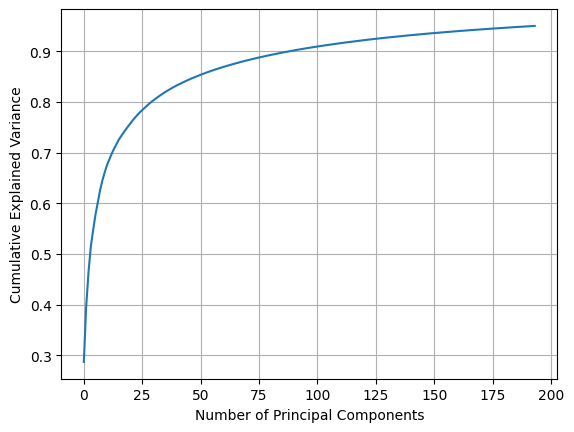

In [73]:
import numpy as np
import matplotlib.pyplot as plt

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [74]:
for i in range (5): 
    print(i)

0
1
2
3
4


In [76]:
X_train_flat = X_train_b.reshape(X_train_b.shape[0], -1)
X_val_flat= X_valid.reshape(X_valid.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [78]:
int(90/4)

22

In [83]:
results= {} 

components = [64, 128, 180, 256, 512, 1024]

    
for i in range (6): 
    pca = PCA(n_components= components[i])
    X_train_pca = pca.fit_transform(X_train_flat)
    X_val_pca = pca.transform(X_val_flat)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(components[i],)),
        tf.keras.layers.Dense(int(components[i]/2), activation = "relu"),
        tf.keras.layers.Dense(int(components[i]/4), activation="relu"),
        tf.keras.layers.Dense(int(components[i]/8), activation="relu"),
        tf.keras.layers.Dense(int(components[i]/16), activation = "relu"), 
        tf.keras.layers.Dense(int(components[i]/32), activation = "relu"), 
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        X_train_pca, y_train_b,
        validation_data=(X_val_pca, y_valid),
        epochs=100,
        callbacks=[early_stop]
    )

    results[i] = max(history.history["val_accuracy"])
    print(f"Best validation accuracy: {results[i]:.4f}")

Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5047 - loss: 0.7449 - val_accuracy: 0.5979 - val_loss: 0.6764
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6151 - loss: 0.6627 - val_accuracy: 0.6802 - val_loss: 0.6335
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6773 - loss: 0.6264 - val_accuracy: 0.6977 - val_loss: 0.6053
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7087 - loss: 0.5947 - val_accuracy: 0.6948 - val_loss: 0.5903
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7449 - loss: 0.5640 - val_accuracy: 0.7035 - val_loss: 0.5830
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7449 - loss: 0.5495 - val_accuracy: 0.7064 - val_loss: 0.5840
Epoch 7/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7534 - loss: 0.5363 - val_accuracy: 0.7064 - val_loss: 0.5799
Epoch 8/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7632 - loss: 0.5245 - val_accu

In [84]:
results

{0: 0.7374030947685242,
 1: 0.7470930218696594,
 2: 0.7374030947685242,
 3: 0.748062014579773,
 4: 0.7344961166381836,
 5: 0.7325581312179565}

let's just train one on 256, another on 128 and see

In [85]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True
)

In [96]:
def build_model(n):
    pca= PCA(n_components= n)
    X_train_pca = pca.fit_transform(X_train_flat)
    X_val_pca = pca.transform(X_val_flat)
    X_test_pca= pca.transform(X_test_flat) 

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n,)),
        tf.keras.layers.Dense(int(n/2), activation = "relu"),
        tf.keras.layers.Dense(int(n/4), activation="relu"),
        tf.keras.layers.Dense(int(n/8), activation="relu"),
        tf.keras.layers.Dense(int(n/16), activation = "relu"), 
        # tf.keras.layers.Dense(int(components[i]/32), activation = "relu"), 
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    history = model.fit(
        X_train_pca, y_train_b,
        validation_data=(X_val_pca, y_valid),
        epochs=100,
        callbacks=[early_stop]
    )

    return X_test_pca, model
    

In [97]:
(X_test_pca, model) = build_model(128)

Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5511 - loss: 0.6845 - val_accuracy: 0.6909 - val_loss: 0.6282
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6947 - loss: 0.6162 - val_accuracy: 0.7074 - val_loss: 0.6057
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7393 - loss: 0.5755 - val_accuracy: 0.7200 - val_loss: 0.5848
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7560 - loss: 0.5382 - val_accuracy: 0.7277 - val_loss: 0.5749
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7901 - loss: 0.4966 - val_accuracy: 0.7393 - val_loss: 0.5733
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8178 - loss: 0.4557 - val_accuracy: 0.7248 - val_loss: 0.5806
Epoch 7/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8297 - loss: 0.4218 - val_accuracy: 0.7219 - val_loss: 0.5870
Epoch 8/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8516 - loss: 0.3895 - val_accu

In [98]:
(X_test_pca256, model256) = build_model(256)

Epoch 1/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6321 - loss: 0.6334 - val_accuracy: 0.7287 - val_loss: 0.5361
Epoch 2/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7560 - loss: 0.5095 - val_accuracy: 0.7335 - val_loss: 0.5238
Epoch 3/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7982 - loss: 0.4367 - val_accuracy: 0.7384 - val_loss: 0.5271
Epoch 4/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8496 - loss: 0.3529 - val_accuracy: 0.7316 - val_loss: 0.5436
Epoch 5/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8915 - loss: 0.2644 - val_accuracy: 0.7432 - val_loss: 0.6047
Epoch 6/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9333 - loss: 0.1828 - val_accuracy: 0.7335 - val_loss: 0.7136
Epoch 7/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9521 - loss: 0.1274 - val_accuracy: 0.7258 - val_loss: 0.9168
Epoch 8/100
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9718 - loss: 0.0901 - val_accu

In [108]:
y128 = model.predict(X_test_pca)
y128 = (y128 >= 0.5).astype(int)

confusion_matrix(y_test, y128)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step


array([[6753, 2247],
       [ 328,  672]], dtype=int64)

Better on non cats.. worse on cats

In [109]:
y256 = model256.predict(X_test_pca256)
y256 = (y256 >= 0.5).astype(int)

confusion_matrix(y_test, y256)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[6276, 2724],
       [ 269,  731]], dtype=int64)

Again.. for reference

In [111]:
absolute_basic= load_model("cifar_dafault_model.keras")

y_test_pred= absolute_basic.predict(X_test)
y_model = np.argmax(y_test_pred, axis=1)
y_model=  (y_model ==3)

confusion_matrix(y_test, y_model)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[8057,  943],
       [ 570,  430]], dtype=int64)

In [113]:
initial_cvnc = load_model("Basic Cat vs Non Cat.keras")

y_test_pred= initial_cvnc.predict(X_test)
y_model = (y_test_pred >=0.5).astype(int)

confusion_matrix(y_test, y_model)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5390, 3610],
       [ 180,  820]], dtype=int64)

Honestly, we've got a good balance of models now...  Our basic model is really good with getting the Cats but messes up the non cats... If we apply PCA, we are able to recover more non cats, however, at the cost of a few cats... 

In [ ]:
model.save(